<a href="https://colab.research.google.com/github/gitmystuff/DTSC4050/blob/main/10-Regression_I/Your_Name_Regression_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

Your Name



## Getting Started

* Colab - get notebook from gitmystuff DTSC4050 repository
* Save a Copy in Drive
* Remove Copy of
* Edit name
* Clean up Colab Notebooks folder
* Submit shared link


## ANOVA: A Quick Bridge From What We Know

We've already covered tests of means (t-tests) for comparing two groups. ANOVA extends that idea to **three or more groups**.

Imagine you're an agricultural researcher testing the effectiveness of three different fertilizers (A, B, and C) on the height of a specific type of plant. You randomly assign 15 plants to three groups:

* **Group 1 (Fertilizer A):** [10, 12, 14, 11, 13] - These are the heights (in centimeters) of the plants treated with Fertilizer A.
* **Group 2 (Fertilizer B):** [18, 20, 19, 21, 22] - Heights of plants treated with Fertilizer B.
* **Group 3 (Fertilizer C):** [5, 7, 6, 8, 9] - Heights of plants treated with Fertilizer C.

**Question:** Do three fertilizers (A, B, C) produce different average plant heights?




**Hypothesis**:
- $H_0:; \mu_1 = \mu_2 = \mu_3$
- We could test each pair
    * $H_0: \mu_1 = \mu_2, \alpha = 0.05$
    * $H_0: \mu_1 = \mu_3, \alpha = 0.05$
    * $H_0: \mu_2 = \mu_3, \alpha = 0.05$
- Overall confidence drops: .95 x .95 x .95 = .857
- In statistics, alpha ($\alpha$)—also known as the significance level—is the probability of committing a Type I error. A Type I error occurs when you reject a true null hypothesis ($H_0$). In plain terms, it is a false positive: you claim to have found a significant effect, relationship, or difference when, in reality, nothing is actually there.
- ANOVA works by computing an F value and compares it to a critical value determined by our degrees of freedom which is determined by the number of groups and number of items in each group
- F value represents the relationship between two types of variance:
    * Between Groups: group mean varies from total mean
    * Within Groups: individual mean varies from group mean

$
F = \frac{Variance Between Groups}{Variance Within Groups} = \frac{\frac{SSG}{df_{groups}}}{\frac{SSE}{df_{error}}} = \frac{\frac{SSG}{ngroups-1}}{\frac{SSE}{(n_{rows}-1)*n_{groups}}}
$

With ANOVA, you see:

Sums of Squares (SS): *Partitioning the Variance*
* Before the test can calculate significance, it has to break down ("partition") where the total variation in your data is coming from. It splits the variance into two main buckets:

    * **Between-Group Sum of Squares ($SS_{\text{between}}$):** Measures how much the group means differ from the overall grand mean. This represents the variance caused by your independent variable (the "effect").
    * **Within-Group Sum of Squares ($SS_{\text{within}}$ or Error):** Measures how much individual data points spread out *inside* their own respective groups. This represents random noise or unexplained error.

F-Statistic: *The Signal-to-Noise Ratio*
* The F-statistic is the actual test statistic calculated by ANOVA. It is a ratio that compares the variance *between* the groups to the variance *within* the groups.
* Mathematically, it represents:

  $$F = \frac{\text{Mean Square Between (Signal)}}{\text{Mean Square Within (Noise)}}$$

    * **An F-statistic close to 1** means the variance between groups is about the same as the random variation inside the groups. There is likely no real effect.
    * **A high F-statistic (well above 1)** means the differences between the group means are much larger than the random noise inside the groups, suggesting a true difference exists.

P-values: *Assessing Statistical Significance*

* The p-value tells you the probability of getting an F-statistic as extreme as the one you observed, assuming that all group means are actually identical in reality (the null hypothesis).
* If the **p-value is low** (typically $\le 0.05$), you reject the null hypothesis. It means the overall differences you are seeing are highly unlikely to be a result of random sampling fluke.

Group Means: *The Actual Values*

* While the F-statistic and p-value tell you *if* a significant difference exists, the individual group means show you the *direction and magnitude* of that difference. They are the literal averages of each group (e.g., Group A average = 85, Group B average = 72, Group C average = 94).

**Note:** A significant ANOVA p-value only tells you that *at least one* group mean is different from the others. It does not tell you *which* specific pairs are different. To find out exactly which groups differ, you would look at the **Group Means** and run a post-hoc tracking test (like Tukey's HSD).


### Variance Between Groups (VBG)

Measures how much the averages of the individual groups differ from the overall average of all the data combined.

* $SSG = \sum_{i=1}^{k} n_i (\bar{x}_i - \bar{x})^2$
* $VBG = SSG/ngroups - 1$

### Variance Within Groups

Measures the spread or dispersion of individual data points inside each specific group around that group's own mean.

* SSE = $\sum_{i=1}^{k} \sum_{j=1}^{n_i} (x_{ij} - \bar{x}_i)^2$
* VWG = SSE / nrows-1(ngroups)

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Example data (replace with your data)
data = pd.DataFrame({
    'value': [10, 12, 14, 11, 13, 18, 20, 19, 21, 22, 5, 7, 6, 8, 9],
    'fertilizer': ['A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'C']
})

# ANOVA
model = ols('value ~ fertilizer', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA Table:\n", anova_table)

# Tukey's HSD test
tukey_result = pairwise_tukeyhsd(data['value'], data['fertilizer'], alpha=0.05)
print("\nTukey's HSD:\n", tukey_result)

#Effect size.
eta_squared = anova_table['sum_sq']['fertilizer'] / anova_table['sum_sq'].sum()
print(f"\nEta Squared : {eta_squared}")

ANOVA Table:
             sum_sq    df     F        PR(>F)
fertilizer   430.0   2.0  86.0  7.694502e-08
Residual      30.0  12.0   NaN           NaN

Tukey's HSD:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B      8.0    0.0   5.3321  10.6679   True
     A      C     -5.0 0.0008  -7.6679  -2.3321   True
     B      C    -13.0    0.0 -15.6679 -10.3321   True
------------------------------------------------------

Eta Squared : 0.9347826086956522


### Interpretation of the Results

1.  **ANOVA Table:**
    * The ANOVA table tells us that there is a statistically significant difference in plant height among the three fertilizer groups. The extremely small p-value (7.694502e-08) indicates a very high level of confidence in this result.
    * The large F-statistic (86.0) also reinforces this finding.
2.  **Tukey's HSD:**
    * The Tukey's HSD test reveals that:
        * Plants treated with Fertilizer B are significantly taller than plants treated with Fertilizer A.
        * Plants treated with Fertilizer A are significantly taller than plants treated with Fertilizer C.
        * Plants treated with Fertilizer B are significantly taller than plants treated with Fertilizer C.
    * Essentially, all three fertilizers produce statistically different plant heights from each other.
3.  **Eta Squared:**
    * The eta squared value (0.9347826086956522) indicates that 93.48% of the variability in plant height can be attributed to the type of fertilizer used. This is a very strong effect, meaning the fertilizer type has a large and important impact on the plant height.

**Practical Implications:**

* Based on this analysis, Fertilizer B is the most effective in promoting plant growth, followed by Fertilizer A, and then Fertilizer C.
* A farmer or gardener could use this information to choose the most effective fertilizer for maximizing plant height.
* The high Eta squared value, means that the choice of fertilizer is extremely important to the outcome of plant height.
* The results of this study would be statistically valid.
* This study could be repeated, and the results would likely be the same.

**Important Note:**

* While the statistical results are strong, real-world applications would also consider other factors, such as the cost of the fertilizers, their environmental impact, and their long-term effects on soil health.
* This example is a simplification. Real world agricultural studies would include many more plants per group, and many more variables.

## The Same Question, Asked as a Regression

ANOVA compares group means. But a "group" is just a categorical predictor. What happens
if we turn `group` into dummy variables and run this as a regression instead?


In [ ]:
# Reuse the same dataset, dummy-code the categorical predictor
reg_data = pd.get_dummies(data, columns=['fertilizer'], drop_first=True)
print(reg_data)

import statsmodels.formula.api as smf

# Multiple linear regression using fertilizer as predictors
ols_model = smf.ols('value ~ fertilizer_B + fertilizer_C', data=reg_data).fit()
print(ols_model.summary())


    value  fertilizer_B  fertilizer_C
0      10         False         False
1      12         False         False
2      14         False         False
3      11         False         False
4      13         False         False
5      18          True         False
6      20          True         False
7      19          True         False
8      21          True         False
9      22          True         False
10      5         False          True
11      7         False          True
12      6         False          True
13      8         False          True
14      9         False          True
                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     86.00
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           7.69e-

Because `drop_first=True` was used, **Fertilizer A** was dropped from the explicit predictors and absorbed into the **Intercept**. This makes Fertilizer A your baseline reference group.

Group Comparisons & Performance Hierarchy

* **Baseline (Fertilizer A):** The Intercept shows that the baseline average plant height for Fertilizer A is **12.00 units**.
* **Fertilizer B Effect:** Using Fertilizer B increases plant height by **8.00 units** compared to Fertilizer A ($12.00 + 8.00 = 20.00$ units total). This positive shift is highly statistically significant ($p < 0.001$).
* **Fertilizer C Effect:** Using Fertilizer C decreases plant height by **5.00 units** compared to Fertilizer A ($12.00 - 5.00 = 7.00$ units total). This negative shift is also highly statistically significant ($p < 0.001$).
* **Conclusion:** Therefore, **Fertilizer B is the most effective** in promoting plant growth (yielding 20 units), followed by Fertilizer A (12 units), and then Fertilizer C (7 units).

Actionable Guidance for Farmers

* A farmer or gardener can directly use these regression coefficients to predict precise outcomes. Choosing Fertilizer B over the standard baseline (A) will reliably maximize plant height by an estimated additional 8 units.

Strength of the Effect (The R-squared / Eta-Squared Link)

* The **R-squared value of 0.935** indicates that **93.5% of the total variance** in plant height is explained by the type of fertilizer used.
* *Note:* This matches your ANOVA Eta-squared calculation exactly because, mathematically, $R^2$ in a categorical linear regression is identical to $\eta^2$ in a one-way ANOVA. This confirms that the choice of fertilizer is extremely critical to the outcome.

Validity & Replicability

* The overall model is statistically valid, as shown by the omnibus F-statistic ($F(2, 12) = 86.00$, $p < 0.001$), proving that the predictors have real explanatory power.
* Residual diagnostics (such as the Omnibus test probability of 0.272 and Jarque-Bera of 0.590) indicate that the underlying assumption of normally distributed errors is met. This means the study could be repeated, and the structural relationships (coefficients) would likely remain stable.

**Understanding the OLS Summary:**

1.  **Model Summary:**

    * **Dep. Variable: value:** This confirms that "value" (plant height in our example) is the dependent variable we're trying to predict.
    * **R-squared: 0.935:** This is a very high R-squared value, indicating that 93.5% of the variance in plant height is explained by the fertilizer groups. This is a very good fit.
    * **Adj. R-squared: 0.924:** This is the adjusted R-squared, which takes into account the number of predictors in the model. It is very close to the R-squared, which is good.
    * **Model: OLS:** This confirms that the model used is Ordinary Least Squares regression.
    * **F-statistic: 86.00:** This is the F-statistic, which tests the overall significance of the model. It's high, indicating strong significance.
    * **Prob (F-statistic): 7.69e-08:** This is the p-value associated with the F-statistic. It's extremely small (close to 0), meaning the overall model is highly statistically significant.
    * **No. Observations: 15:** This is the number of data points used in the regression.
    * **Df Residuals: 12:** This is the degrees of freedom for the residuals (error).
    * **Df Model: 2:** This is the degrees of freedom for the model (number of predictors).

2.  **Coefficients Table:**

    * **coef:** These are the estimated coefficients for each predictor.
    * **std err:** This is the standard error of the coefficients.
    * **t:** This is the t-statistic, which tests the significance of each coefficient.
    * **P > |t|:** This is the p-value associated with each t-statistic. All are 0.000, meaning all coefficients are highly statistically significant.
    * **[0.025 0.975]:** This is the 95% confidence interval for each coefficient.

3.  **Omnibus/Durbin-Watson/Skew/Kurtosis:**

    * These are diagnostic statistics that assess the model's assumptions.
        * **Omnibus and Prob(Omnibus):** These test for the normality of the residuals. A p-value above 0.05 suggests that the residuals are normally distributed.
        * **Durbin-Watson:** This tests for autocorrelation (dependence) in the residuals. A value close to 2 is generally good.
        * **Skew and Kurtosis:** These describe the shape of the residual distribution.

4.  **Jarque-Bera (JB):**

    * This is another test for the normality of the residuals.

5.  **Cond. No.:**

    * This is the condition number, which tests for multicollinearity (high correlation between predictors). A high value might indicate multicollinearity.

**NOTES**:

* T.True indicates how the categorical variable (in this case, "fertilizer") has been coded using dummy variables
* Fertilizer A becomes our reference or comparison group
* We don't need a group_A[T.True] because the intercept provides the information we need about group A.

In [ ]:
# Put the two results side by side
print(f"ANOVA F-statistic: {anova_table['F']['fertilizer']:.2f},  p-value: {anova_table['PR(>F)']['fertilizer']:.2e}")
print(f"OLS   F-statistic: {ols_model.fvalue:.2f},  p-value: {ols_model.f_pvalue:.2e}")
print()
print(f"Eta squared (ANOVA): {eta_squared:.3f}")
print(f"R-squared   (OLS):   {ols_model.rsquared:.3f}")


ANOVA F-statistic: 86.00,  p-value: 7.69e-08
OLS   F-statistic: 86.00,  p-value: 7.69e-08

Eta squared (ANOVA): 0.935
R-squared   (OLS):   0.935


**The punchline:** identical F-statistics, identical p-values, and eta squared equals
R-squared. This isn't a coincidence — ANOVA *is* a linear regression where the predictor
happens to be categorical. Both are special cases of the **general linear model**:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \epsilon$$

ANOVA restricts $x$ to categories (via dummy coding). Regression lets $x$ be continuous — which makes it a far more flexible tool.


## Simple Linear Regression

$$y = mx + b$$

$$m = \frac{N\sum{(xy)} - \sum{x}\sum{y}}{N\sum{x^2} - (\sum{x})^2} \qquad
b = \frac{\sum{y} - m\sum{x}}{N}$$

Let's compute this by hand first, then check it against Python's tools.


In [ ]:
# https://www.mathsisfun.com/data/least-squares-regression.html
import numpy as np
import pandas as pd

x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 3, 2, 3, 5])

def xy(r):
    return r.x * r.y

m_table = pd.DataFrame({'x': x, 'y': y})
m_table['x^2'] = m_table['x'].apply(lambda v: v**2)
m_table['xy'] = m_table.apply(xy, axis=1)
print(m_table)

N = len(x)
sums = list(m_table.sum())
m = (N * sums[3] - sums[0] * sums[1]) / (N * sums[2] - sums[0]**2)
b = (sums[1] - m * sums[0]) / N
print(f"\nm (slope): {m:.2f}")
print(f"b (intercept): {b:.2f}")


   x  y  x^2  xy
0  1  1    1   1
1  2  3    4   6
2  3  2    9   6
3  4  3   16  12
4  5  5   25  25

m (slope): 0.80
b (intercept): 0.40


Solving for m:

$$m = \frac{N\sum{(xy)} - \sum{x}\sum{y}}{N\sum{x^2} - (\sum{x})^2}$$

Step 1: Calculate the Column Sums and Identify $N$

First, count your total number of observations ($N$) and sum up each column in your dataset:

* **$N$ (Number of pairs):** $5$
* **$\sum xy$** $= 1 + 6 + 6 + 12 + 25 = \mathbf{50}$
* **$\sum x$** $= 1 + 2 + 3 + 4 + 5 = \mathbf{15}$
* **$\sum y$** $= 1 + 3 + 2 + 3 + 5 = \mathbf{14}$
* **$\sum x^2$** $= 1 + 4 + 9 + 16 + 25 = \mathbf{55}$


Step 2: Solve the Numerator

The numerator represents the covariation between $x$ and $y$, scaled by the sample size:

$$\text{Numerator} = N \sum(xy) - \left(\sum x \cdot \sum y\right)$$

Plugging in the sums:


$$\text{Numerator} = 5(50) - (15 \cdot 14)$$

$$\text{Numerator} = 250 - 210 = \mathbf{40}$$

Step 3: Solve the Denominator

The denominator represents the scaled variance of the independent variable $x$.

> **Crucial Distinction:** Note the difference between $\sum x^2$ (summing the squared values) and $(\sum x)^2$ (squaring the total sum of $x$).

$$\text{Denominator} = N \sum x^2 - \left(\sum x\right)^2$$

Plugging in the sums:


$$\text{Denominator} = 5(55) - (15)^2$$

$$\text{Denominator} = 275 - 225 = \mathbf{50}$$

Step 4: Final Calculation for $m$

Divide the numerator by the denominator to get your slope ($m$):

$$m = \frac{40}{50} = \mathbf{0.8}$$



### Correlation vs. Simple Linear Regression

Correlation tells us the strength and direction of a linear relationship. Regression goes
further: it estimates the actual line we'd use to *predict* $y$ from $x$.

$$y_i = \alpha + \beta x_i + \epsilon_i$$

$\alpha$ and $\beta$ are the parameters we're solving for. $\epsilon$ is the error term —
whatever $x$ doesn't explain about $y$. The sum (and mean) of residuals is always zero for
the true line of best fit.


a = 0.4, b = 0.8
x values: [1 2 3 4 5]
y values: [1 3 2 3 5]
predicted values: [np.float64(1.2), np.float64(2.0), np.float64(2.8), np.float64(3.6), np.float64(4.4)]


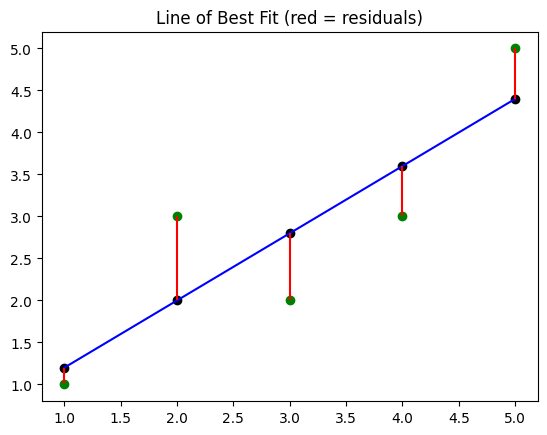

In [ ]:
import matplotlib.pyplot as plt

plt.plot(x, y, 'go')

b_fit, a_fit = np.polyfit(x, y, 1)
y_hat = [round(a_fit + (b_fit * xi), 2) for xi in x]
print(f'a = {a_fit:.1f}, b = {b_fit:.1f}')
print(f'x values: {x}')
print(f'y values: {y}')
print(f'predicted values: {y_hat}')

plt.plot(x, y_hat, 'ko')
plt.plot(x, a_fit + b_fit * x, 'b')
plt.vlines(x, y, a_fit + b_fit * x, 'r')
plt.title('Line of Best Fit (red = residuals)')
plt.show()


### Deriving $\widehat{\beta}$ Step by Step

$$\widehat{\beta} = \frac{s_{x,y}}{s^2_x} = r_{xy}\frac{s_y}{s_x}  = \frac{N\sum{(xy)} - \sum{x}\sum{y}}{N\sum{x^2} - (\sum{x})^2} = \frac{\sum{(x - \bar{x})(y - \bar{y})}}{\sum(x - \bar{x})^2}$$

#### The Left-Hand Side

* **$\widehat{\beta}$ (Beta hat):** The **estimated slope coefficient** (or regression weight) for the independent variable $x$. It represents the predicted change in the dependent variable $y$ for a one-unit increase in $x$.

#### First Formulation (Covariance Method): $\frac{s_{x,y}}{s_x^2}$

* **$s_{x,y}$:** The **sample covariance** between variables $x$ and $y$. It measures the direction and linear association of their joint variability.
* **$s_x^2$:** The **sample variance** of the independent variable $x$.
* *Terminology for the ratio:* The slope is the **covariance of $x$ and $y$ divided by the variance of $x$**.

#### Second Formulation (Correlation Method): $r_{xy} \frac{s_y}{s_x}$

* **$r_{xy}$:** The **Pearson correlation coefficient** (sample correlation) between $x$ and $y$. It measures the strength and direction of their linear relationship on a scale from $-1$ to $+1$.
* **$s_y$:** The **sample standard deviation** of the dependent variable $y$.
* **$s_x$:** The **sample standard deviation** of the independent variable $x$.
* *Terminology for the ratio:* The slope is the **correlation coefficient scaled by the ratio of the standard deviations** of $y$ and $x$.

#### Third Formulation (The Raw/Computational Formula)

#### Final Formulation (The Mean-Deviation Method): $\frac{\sum(x - \bar{x})(y - \bar{y})}{\sum(x - \bar{x})^2}$

* **$\sum(x - \bar{x})(y - \bar{y})$:** The **Sum of Products (SP)** or **Sum of Squares for Error/Covariation ($SS_{xy}$)**. It is the numerator used to calculate sample covariance, representing the sum of the deviations of $x$ multiplied by the deviations of $y$.
* **$\sum(x - \bar{x})^2$:** The **Sum of Squared Deviations** (or **Sum of Squares, $SS_x$**) for the variable $x$. It is the numerator used to calculate sample variance, representing the total variation of $x$ around its own mean ($\bar{x}$).


### Between Group/Within Group Terms

#### **SSG (Sum of Squares Between Groups)**

* *Also known as:* **SSR** (Sum of Squares due to Regression) in a regression context, or **SSB** (Sum of Squares Between).
* *What it measures:* The variation **between** the different groups or the variation explained by your model. It calculates how far each group's average is from the overall grand mean of all the data.
* *Analogy:* The "Signal."

#### **SSE (Sum of Squares Within Groups / Error)**

* *Also known as:* **SSW** (Sum of Squares Within) or Residual Sum of Squares (**RSS**).
* *What it measures:* The variation **within** the groups that cannot be explained by the group categories or the model. It calculates how far individual data points are from their own group's average.
* *Analogy:* The "Noise" or unexplained error.

#### **SST (Total Sum of Squares)**

* *What it measures:* The **total variation** in the entire dataset. It calculates how far every single data point is from the overall grand mean, completely ignoring what group they belong to.
* *Analogy:* The total amount of variation you have to work with.

The fundamental rule of ANOVA is that total variation can be perfectly split into explained and unexplained parts:

$$\text{SST} = \text{SSG} + \text{SSE}$$

Once you have these sums of squares, you divide them by their respective **degrees of freedom ($df$)** to get the actual variances (Mean Squares), which finally gives you the $F$-statistic:

$$\text{Variance Between (MS}_{ \text{between} }) = \frac{\text{SSG}}{df_{\text{group}}}$$

$$\text{Variance Within (MS}_{ \text{within} }) = \frac{\text{SSE}}{df_{\text{error}}}$$

$$F = \frac{\text{MS}_{\text{between}}}{\text{MS}_{\text{within}}}$$

$\widehat{\beta} = \frac{\sum{(x - \bar{x})(y - \bar{y})}}{\sum(x - \bar{x})^2}$

Let's build this from scratch.

In [ ]:
x_mean = sum(i for i in x) / len(x)
y_mean = sum(i for i in y) / len(y)
print(f"x_mean: {x_mean}, y_mean: {y_mean}")


x_mean: 3.0, y_mean: 2.8


In [ ]:
# Numerator: sum((x - x_mean) * (y - y_mean))
numerator = sum([(i - x_mean) * (j - y_mean) for i, j in zip(x, y)])
print(f"numerator: {numerator}")


numerator: 8.0


In [ ]:
# Denominator: sum((x - x_mean)^2)
denominator = sum((i - x_mean)**2 for i in x)
print(f"denominator: {denominator}")


denominator: 10.0


In [ ]:
beta = numerator / denominator
print(f"beta: {beta}")


beta: 0.8


Let's find $\alpha$:

$\widehat{\alpha} = \bar{y} - \beta\bar{x}$


In [ ]:
alpha = round(y_mean - (beta * x_mean), 2)
print(f"alpha: {alpha}")
print(f"\nOur regression equation: y = {alpha} + {beta}(X)")


alpha: 0.4

Our regression equation: y = 0.4 + 0.8(X)


### Checking Our Work: Two Computational Tools

We just derived $\alpha$ and $\beta$ by hand. Let's confirm the same answer using
`scipy` (a quick statistical check) and `scikit-learn` (the tool we'll use going forward
for modeling).


In [ ]:
import scipy.stats as stats

model = stats.linregress(x, y)
print(f'y = {model.intercept:.2f} + {model.slope:.2f}(X)')


y = 0.40 + 0.80(X)


In [ ]:
from sklearn.linear_model import LinearRegression

x_reshaped = x.reshape(-1, 1)
sk_model = LinearRegression()
sk_model.fit(x_reshaped, y)
print(f'y = {sk_model.intercept_:.2f} + {sk_model.coef_[0]:.2f}(X)')


y = 0.40 + 0.80(X)


## Linear Algebra

* $y_i = \theta^TX_i + \epsilon_i$
* $h_\theta(x) = \theta_0 + \theta_1x_1$

### Matrix Multiplication (x = x.reshape(-1, 1))

In mathematics, particularly in linear algebra, matrix multiplication is a binary operation that produces a matrix from two matrices. For matrix multiplication, the number of columns in the first matrix must be equal to the number of rows in the second matrix. The resulting matrix, known as the matrix product, has the number of rows of the first and the number of columns of the second matrix. The product of matrices A and B is denoted as AB.

https://en.wikipedia.org/wiki/Matrix_multiplication

m = rows; n = columns; (m, n) can be multiplied with another (m, n) if n from first matrix is equal to m for second matrix

In [ ]:
# Let's look at the x data
X = np.array([1, 2, 3, 4, 5])
X

array([1, 2, 3, 4, 5])

In [ ]:
# Look at the y data
y = np.array([1, 3, 2, 3, 5])
y

array([1, 3, 2, 3, 5])

To be able to multiply two matrices, the number of columns in the first matrix must equal the number of rows in the second matrix (array).

In [ ]:
# Reshape x so that the columns in x equals the number of rows in y
y = y.reshape(-1, 1)
y

array([[1],
       [3],
       [2],
       [3],
       [5]])

In [ ]:
X = np.append(arr = np.ones((5, 1)).astype(int), values = X.reshape(-1, 1), axis = 1)
print('weights = ', np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y))

weights =  [[0.4]
 [0.8]]


### Why Matrix Multiplication?

Linear algebra is often used in data science / machine learning which includes matrix multiplication. To stay within the scope of this course we will simply say that because of the large number of features that X can potentially represent, it is more efficient to use matrix multiplication.

Because matrix multiplication is such a central operation in many numerical algorithms, much work has been invested in making matrix multiplication algorithms efficient. Applications of matrix multiplication in computational problems are found in many fields including scientific computing and pattern recognition and in seemingly unrelated problems such as counting the paths through a graph.

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes

# 1. Directly retrieve X and y from the dataset
X_raw, y = load_diabetes(return_X_y=True)

# y comes out as a 1D array; reshape it to a 2D column vector for matrix dot products
y = y.reshape(-1, 1)

# 2. Get the total number of samples dynamically
num_samples = X_raw.shape[0]

# 3. Append a column of ones matching the dataset's length
X = np.append(arr = np.ones((num_samples, 1)).astype(int), values = X_raw, axis = 1)

# 4. Calculate all weights simultaneously using the Normal Equation
weights = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

# 5. Display the results
print(f"Dataset Dimensions: {X_raw.shape[0]} rows, {X_raw.shape[1]} features")
print(f"Design Matrix Shape: {X.shape}\n")
print(f"Intercept (w0) = {weights[0][0]:.4f}")

# Map each slope to its respective feature name
feature_names = load_diabetes().feature_names
print("\nFeature Coefficients (Slopes):")
for name, weight in zip(feature_names, weights[1:]):
    print(f"{name:<10}---: {weight[0]:.4f}")

Dataset Dimensions: 442 rows, 10 features
Design Matrix Shape: (442, 11)

Intercept (w0) = 152.1335

Feature Coefficients (Slopes):
age       ---: -10.0099
sex       ---: -239.8156
bmi       ---: 519.8459
bp        ---: 324.3846
s1        ---: -792.1756
s2        ---: 476.7390
s3        ---: 101.0433
s4        ---: 177.0632
s5        ---: 751.2737
s6        ---: 67.6267


## Linear vs. Nonlinear Relationships

**Linear regression** assumes a straight-line relationship: as $x$ changes, $y$ changes by
a consistent, proportional amount.

$$y = \beta_0 + \beta_1 x + \epsilon$$


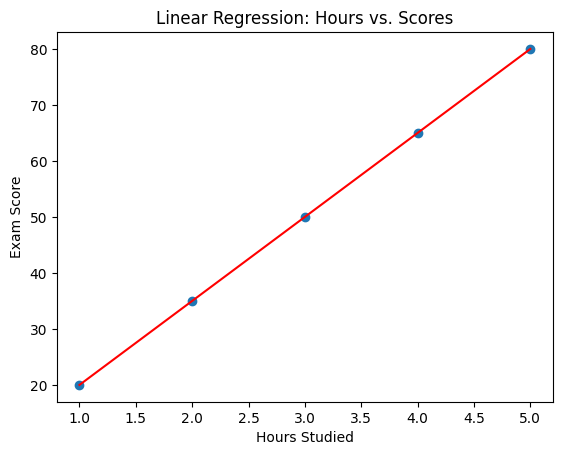

Intercept: 4.999999999999993
Slope: 15.000000000000002


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Example: hours studied vs. exam score
hours = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
scores = np.array([20, 35, 50, 65, 80])

model = LinearRegression()
model.fit(hours, scores)
predictions = model.predict(hours)

plt.scatter(hours, scores)
plt.plot(hours, predictions, color='red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression: Hours vs. Scores")
plt.show()

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


**Nonlinear regression** models relationships that curve rather than follow a straight
line — polynomial, exponential, logarithmic, etc.

**Example:** drug concentration in the bloodstream over time often follows a curve, not a
straight line.


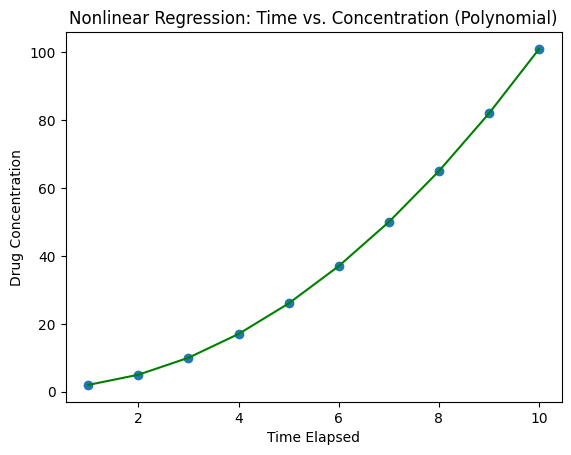

Coefficients: [ 0.00000000e+00 -6.32827124e-15  1.00000000e+00]


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

time = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
concentration = np.array([2, 5, 10, 17, 26, 37, 50, 65, 82, 101])

poly = PolynomialFeatures(degree=2)
time_poly = poly.fit_transform(time)

poly_model = LinearRegression()
poly_model.fit(time_poly, concentration)
predictions = poly_model.predict(time_poly)

plt.scatter(time, concentration)
plt.plot(time, predictions, color='green')
plt.xlabel("Time Elapsed")
plt.ylabel("Drug Concentration")
plt.title("Nonlinear Regression: Time vs. Concentration (Polynomial)")
plt.show()

print("Coefficients:", poly_model.coef_)


## Takeaways

- ANOVA and regression are both special cases of the general linear model — dummy-coding
  a categorical group variable in a regression reproduces ANOVA's F-statistic exactly.
- Simple linear regression finds the $\alpha$ (intercept) and $\beta$ (slope) that
  minimize squared residuals — we derived this by hand and confirmed it with `scipy` and
  `scikit-learn`.
- Not every relationship is linear — always look at the data before assuming a straight
  line fits.
